# Intent Classification with Out-of-Scope Detection on CLINC150

**Course:** NNDL — Lab 10 (Fine-Tuning LLM)
**Task:** Train classifiers over the 150 in-scope CLINC intents **plus** an explicit `oos` label and compare four approaches under a fixed task / split / label space / metric protocol.

### Methods compared

| # | Model | Label space | OOS handling |
|---|---|---|---|
| A | TF-IDF + LinearSVC | 151 (oos as class) | Joint classification |
| B | TF-IDF + LinearSVC | 150 (in-scope only) | Threshold on max margin (MSP analogue) |
| C | DistilBERT + LoRA (PEFT) | 151 (oos as class) | Joint classification |
| D | DistilBERT + LoRA (PEFT) | 150 (in-scope only) | Threshold on MSP / energy score |

### Evaluation protocol — "Merge 2 Testset"

Following the lab instructions, **one** classifier with **one** OOS threshold policy is applied to:

1. **In-scope test set** — the subset of CLINC `test` where `intent != oos`. Metrics: accuracy, macro-F1 over the 150 in-scope classes (a prediction of `oos` here counts as wrong).
2. **OOS test set** — the subset where `intent == oos`. Metric: OOS recall (= acceptance rate as `oos`).
3. **Combined test set** — the union. Metrics: joint accuracy & macro-F1 over 151 classes; OOS precision/recall/F1; AUROC of the OOS-score.

### Environment

Tested on Kaggle Notebooks with T4 / P100 GPU. Set `Accelerator → GPU T4 x2` (or P100) in Notebook settings.

## 1. Setup

Kaggle base image already ships `transformers`, `datasets`, `scikit-learn`, `torch`. We only need to add **PEFT** for LoRA.

In [4]:
# install peft if missing (Kaggle usually has transformers/datasets)
import importlib, subprocess, sys

def _ensure(pkg, import_name=None):
    name = import_name or pkg
    try:
        importlib.import_module(name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

_ensure("peft")
_ensure("evaluate")

In [5]:
import os, random, json, math, time
import numpy as np
import pandas as pd
import torch

import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve,
)
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
)
from peft import LoraConfig, get_peft_model, TaskType

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE, "| torch:", torch.__version__)

Device: cpu | torch: 2.12.0+cpu


In [19]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve,
)

## 2. Data — CLINC150 (Kaggle dataset by Stefan Larson)

Source: [stefanlarson/outofscope-intent-classification-dataset](https://www.kaggle.com/datasets/stefanlarson/outofscope-intent-classification-dataset) — mirrors `clinc/oos-eval` on GitHub.

**Add this dataset to the notebook:** in the right-hand panel of Kaggle → `+ Add Data` → search "outofscope intent" → attach. The files appear at `/kaggle/input/outofscope-intent-classification-dataset/`.

The dataset ships several JSON files. We use the **`data_full.json`** layout (one file with 6 top-level keys: `train` / `val` / `test` / `oos_train` / `oos_val` / `oos_test`). Each value is a list of `[text, intent_label]` pairs, where `intent_label` is a string (`"balance"`, `"oos"`, …). We build `label2id` ourselves and put `oos` at the **last index** so it's easy to find.

If the attached dataset has the alternative layout (`is_*.json` + `oos_*.json` as 6 separate files), the loader falls back to that automatically.

In [12]:
import json, os
from pathlib import Path

# Search anywhere under /kaggle/input/ — the exact slug of the attached
# dataset folder is not assumed (Kaggle uses different casings/dashes).
KAGGLE_INPUT_ROOT = Path("/kaggle/input")

# 1. Show everything that's inside the attached datasets (debug aid)
for root, _, files in os.walk(KAGGLE_INPUT_ROOT):
    for f in sorted(files):
        full = os.path.join(root, f)
        print(f"  {os.path.getsize(full):>10}  {full}")

In [13]:
import json
import urllib.request
from pathlib import Path
import pandas as pd
import numpy as np

# ========== 1. Загрузка data_full.json ==========
DATA_DIR = Path("./clinc_data")
DATA_DIR.mkdir(exist_ok=True)
DATA_FILE = DATA_DIR / "data_full.json"

if not DATA_FILE.exists():
    print("Скачиваем data_full.json...")
    url = "https://raw.githubusercontent.com/clinc/oos-eval/master/data/data_full.json"
    urllib.request.urlretrieve(url, DATA_FILE)
    print("Готово!")

with open(DATA_FILE, 'r', encoding='utf-8') as f:
    data_full = json.load(f)

print(f"Ключи в файле: {list(data_full.keys())}")

# ========== 2. Преобразование данных ==========
def normalize_pairs(lst):
    """Преобразует список [text, intent] в удобный формат"""
    return [(item[0], item[1]) for item in lst]

raw = {
    "train": normalize_pairs(data_full["train"]) + normalize_pairs(data_full["oos_train"]),
    "val": normalize_pairs(data_full["val"]) + normalize_pairs(data_full["oos_val"]),
    "test": normalize_pairs(data_full["test"]) + normalize_pairs(data_full["oos_test"]),
}

print(f"Train: {len(raw['train'])} примеров")
print(f"Val: {len(raw['val'])} примеров")
print(f"Test: {len(raw['test'])} примеров")
print(f"Пример: {raw['train'][0]}")

# ========== 3. Создание label2id ==========
all_labels = sorted({lab for split in raw.values() for _, lab in split if lab != "oos"})
label_names = all_labels + ["oos"]
label2id = {lab: i for i, lab in enumerate(label_names)}
id2label = {i: lab for lab, i in label2id.items()}

OOS_LABEL = label2id["oos"]
N_LABELS_151 = len(label_names)
N_LABELS_150 = N_LABELS_151 - 1

print(f"\nВсего меток: {N_LABELS_151} (oos индекс = {OOS_LABEL})")
print(f"Первые 10 меток: {label_names[:10]}")

# ========== 4. Создание DataFrame ==========
def to_df(pairs):
    return pd.DataFrame({
        "text": [t for t, _ in pairs],
        "label": [label2id[l] for _, l in pairs],
    })

train_df = to_df(raw["train"])
val_df = to_df(raw["val"])
test_df = to_df(raw["test"])

print(f"\ntrain: {len(train_df)} | val: {len(val_df)} | test: {len(test_df)}")
print(f"OOS в train: {(train_df.label == OOS_LABEL).sum()}")
print(f"OOS в val: {(val_df.label == OOS_LABEL).sum()}")
print(f"OOS в test: {(test_df.label == OOS_LABEL).sum()}")

# ========== 5. Создание in-scope сплита для обучения ==========
from sklearn.model_selection import train_test_split

combined_df = pd.concat([train_df, val_df], ignore_index=True)
combined_inscope = combined_df[combined_df.label != OOS_LABEL].copy()

train_base_df, test_local_df = train_test_split(
    combined_inscope[["text", "label"]],
    test_size=0.1,
    random_state=42,
    stratify=combined_inscope["label"],
)

label_to_name = {v: k for k, v in label2id.items()}
train_base_df["intent"] = train_base_df["label"].map(label_to_name)
test_local_df["intent"] = test_local_df["label"].map(label_to_name)

print(f"\nTrain base (in-scope only): {len(train_base_df)}")
print(f"Test local (in-scope only): {len(test_local_df)}")
print(train_base_df.head())

Ключи в файле: ['oos_val', 'val', 'train', 'oos_test', 'test', 'oos_train']
Train: 15100 примеров
Val: 3100 примеров
Test: 5500 примеров
Пример: ('what expression would i use to say i love you if i were an italian', 'translate')

Всего меток: 151 (oos индекс = 150)
Первые 10 меток: ['accept_reservations', 'account_blocked', 'alarm', 'application_status', 'apr', 'are_you_a_bot', 'balance', 'bill_balance', 'bill_due', 'book_flight']

train: 15100 | val: 3100 | test: 5500
OOS в train: 100
OOS в val: 100
OOS в test: 1000

Train base (in-scope only): 16200
Test local (in-scope only): 1800
                                                 text  label            intent
4806                           what is my health plan     57         insurance
16769             schedule my meeting with jim at 3pm    109  schedule_meeting
17394        do you need shots before going to russia    138          vaccines
9110                 what's my current spending limit     28      credit_limit
5202   what's 

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

print("=== SVM Baseline ===")
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2, max_features=50000)),
    ('clf', LinearSVC(C=1.0, max_iter=1000)),
])

svm_pipeline.fit(train_base_df['text'], train_base_df['intent'])
svm_pred = svm_pipeline.predict(test_local_df['text'])

svm_acc = accuracy_score(test_local_df['intent'], svm_pred)
svm_macro_f1 = f1_score(test_local_df['intent'], svm_pred, average='macro')

print(f"SVM accuracy: {svm_acc:.4f}")
print(f"SVM macro F1: {svm_macro_f1:.4f}")

=== SVM Baseline ===
SVM accuracy: 0.9500
SVM macro F1: 0.9499


In [15]:
# Build a stable label→id map with `oos` pinned to the last index.
all_labels = sorted({lab for pairs in raw.values() for _, lab in pairs if lab != "oos"})
label_names = all_labels + ["oos"]
label2id    = {lab: i for i, lab in enumerate(label_names)}
id2label    = {i: lab for lab, i in label2id.items()}

OOS_LABEL    = label2id["oos"]
N_LABELS_151 = len(label_names)
N_LABELS_150 = N_LABELS_151 - 1
print(f"Total labels: {N_LABELS_151} (oos index = {OOS_LABEL})")

def to_df(pairs):
    return pd.DataFrame({
        "text":  [t for t, _ in pairs],
        "label": [label2id[l] for _, l in pairs],
    })

train_df = to_df(raw["train"])
val_df   = to_df(raw["val"])
test_df  = to_df(raw["test"])

print("train:", len(train_df), "| val:", len(val_df), "| test:", len(test_df))
print("oos in train/val/test:",
      (train_df.label == OOS_LABEL).sum(),
      (val_df.label   == OOS_LABEL).sum(),
      (test_df.label  == OOS_LABEL).sum())

Total labels: 151 (oos index = 150)
train: 15100 | val: 3100 | test: 5500
oos in train/val/test: 100 100 1000


**Two label spaces:**

- 151-way: keep `oos` as a regular class.
- 150-way: drop all `oos` examples from training and remap labels to contiguous `[0, 149]`. At test time the model only sees in-scope classes; OOS is detected by thresholding.

In [16]:
# 150-way: drop oos from training and remap label ids to be contiguous
inscope_labels = [i for i in range(N_LABELS_151) if i != OOS_LABEL]
id151_to_id150 = {old: new for new, old in enumerate(inscope_labels)}
id150_to_id151 = {new: old for old, new in id151_to_id150.items()}

def to_150(df):
    sub = df[df.label != OOS_LABEL].copy()
    sub["label"] = sub["label"].map(id151_to_id150)
    return sub.reset_index(drop=True)

train_df_150 = to_150(train_df)
val_df_150   = to_150(val_df)
# test stays full — we still want to see how 150-way model handles oos via threshold
print("train_150:", len(train_df_150), "| val_150:", len(val_df_150))

train_150: 15000 | val_150: 3000


## 3. Evaluation utilities — Merge 2 Testset

`evaluate_all` produces a comparable metric bundle. Inputs are predictions and (optionally) an `oos_score` over the **whole** test set; the function splits internally into in-scope / OOS / combined.

- `y_true_151` / `y_pred_151` — predictions in the **151-class space** (a 150-way model must already convert "below threshold" to `OOS_LABEL`).
- `oos_score` — scalar where **higher = more likely OOS**. Used for AUROC, threshold-free.

In [17]:
def evaluate_all(y_true_151, y_pred_151, oos_score=None, name=""):
    y_true = np.asarray(y_true_151)
    y_pred = np.asarray(y_pred_151)

    # --- (1) In-scope test set: rows where true != oos
    in_mask  = y_true != OOS_LABEL
    n_in     = int(in_mask.sum())
    acc_in   = accuracy_score(y_true[in_mask], y_pred[in_mask])
    f1_in    = f1_score(y_true[in_mask], y_pred[in_mask],
                        average="macro", zero_division=0)
    # false-alarm rate: in-scope rows that the model rejected as oos
    fa_rate  = float((y_pred[in_mask] == OOS_LABEL).mean())

    # --- (2) OOS test set: rows where true == oos
    oos_mask = ~in_mask
    n_oos    = int(oos_mask.sum())
    oos_recall = float((y_pred[oos_mask] == OOS_LABEL).mean()) if n_oos else 0.0

    # --- (3) Combined (all 151)
    acc_all  = accuracy_score(y_true, y_pred)
    f1_all   = f1_score(y_true, y_pred, average="macro", zero_division=0)

    # Binary OOS detection on combined
    y_true_bin = oos_mask.astype(int)
    y_pred_bin = (y_pred == OOS_LABEL).astype(int)
    p, r, f, _ = precision_recall_fscore_support(
        y_true_bin, y_pred_bin, average="binary", zero_division=0
    )
    auroc = None
    if oos_score is not None and n_oos > 0:
        auroc = roc_auc_score(y_true_bin, oos_score)

    return {
        "method":            name,
        # in-scope test
        "in.acc":            acc_in,
        "in.macroF1":        f1_in,
        "in.false_alarm":    fa_rate,
        "in.N":              n_in,
        # oos test
        "oos.recall":        oos_recall,
        "oos.N":             n_oos,
        # combined
        "all.acc":           acc_all,
        "all.macroF1":       f1_all,
        "all.oos_precision": p,
        "all.oos_f1":        f,
        "all.oos_auroc":     auroc,
    }


def fmt_row(r):
    return (f"{r['method']:34s} | "
            f"IN acc={r['in.acc']:.4f} F1={r['in.macroF1']:.4f} FA={r['in.false_alarm']:.4f} | "
            f"OOS recall={r['oos.recall']:.4f} | "
            f"ALL acc={r['all.acc']:.4f} F1={r['all.macroF1']:.4f} "
            f"AUROC={(r['all.oos_auroc'] or float('nan')):.4f}")


results_log = []

## 4. Method A — TF-IDF + LinearSVC (151-way)

Classic strong baseline. Word 1–2-grams + linear SVM. We treat `oos` as a regular class.

In [20]:
tfidf_151 = TfidfVectorizer(
    ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True,
)
X_train = tfidf_151.fit_transform(train_df["text"])
X_val   = tfidf_151.transform(val_df["text"])
X_test  = tfidf_151.transform(test_df["text"])

svm_151 = LinearSVC(C=1.0)
svm_151.fit(X_train, train_df["label"])

y_pred = svm_151.predict(X_test)
# decision_function returns shape (n, n_classes); use confidence of the
# predicted OOS-vs-not as the OOS score
df_scores = svm_151.decision_function(X_test)
oos_score = df_scores[:, OOS_LABEL]            # margin toward the oos class

res = evaluate_all(test_df["label"].values, y_pred, oos_score, "A) SVM 151-way")
results_log.append(res); print(fmt_row(res))

A) SVM 151-way                     | IN acc=0.9107 F1=0.9049 FA=0.0029 | OOS recall=0.1630 | ALL acc=0.7747 F1=0.8345 AUROC=0.7710


## 5. Method B — TF-IDF + LinearSVC (150-way) + threshold

Train on in-scope only (150 classes). At inference, the **maximum decision-function margin** is our confidence: low margin → predict OOS. We pick the threshold on the **validation set** to maximise joint accuracy across the 151-class space.

In [21]:
tfidf_150 = TfidfVectorizer(
    ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True,
)
X_tr  = tfidf_150.fit_transform(train_df_150["text"])
X_val = tfidf_150.transform(val_df["text"])      # full val (includes oos)
X_te  = tfidf_150.transform(test_df["text"])

svm_150 = LinearSVC(C=1.0)
svm_150.fit(X_tr, train_df_150["label"])

val_margins = svm_150.decision_function(X_val)
val_pred150 = val_margins.argmax(axis=1)
val_conf    = val_margins.max(axis=1)            # higher = more confident in-scope

# sweep threshold on val
y_val_151 = val_df["label"].values
candidates = np.quantile(val_conf, np.linspace(0.01, 0.5, 50))
best_t, best_acc = None, -1
for t in candidates:
    pred_151 = np.where(val_conf < t, OOS_LABEL,
                        np.vectorize(id150_to_id151.get)(val_pred150))
    acc = accuracy_score(y_val_151, pred_151)
    if acc > best_acc:
        best_acc, best_t = acc, t

print(f"Best threshold on val = {best_t:.4f}  (val acc_joint = {best_acc:.4f})")

# evaluate on test
te_margins = svm_150.decision_function(X_te)
te_pred150 = te_margins.argmax(axis=1)
te_conf    = te_margins.max(axis=1)
te_pred151 = np.where(te_conf < best_t, OOS_LABEL,
                      np.vectorize(id150_to_id151.get)(te_pred150))

# OOS score: lower confidence ⇒ more OOS-like, so use negative
oos_score_B = -te_conf
res = evaluate_all(test_df["label"].values, te_pred151, oos_score_B,
                   "B) SVM 150-way + threshold")
results_log.append(res); print(fmt_row(res))

Best threshold on val = -0.5683  (val acc_joint = 0.8861)
B) SVM 150-way + threshold         | IN acc=0.9056 F1=0.9074 FA=0.0200 | OOS recall=0.4120 | ALL acc=0.8158 F1=0.8590 AUROC=0.9306


## 6. Method C — DistilBERT + LoRA (151-way)

`distilbert-base-uncased` fine-tuned with PEFT LoRA on the joint 151-class task. We follow the teacher's recipe (r=8, α=16, target `q_lin`/`v_lin`, dropout 0.1) but train slightly fewer epochs to save Kaggle GPU time.

In [23]:
from datasets import Dataset, DatasetDict

print("✅ Dataset и DatasetDict импортированы")

✅ Dataset и DatasetDict импортированы


In [24]:
# Для работы с датасетами
from datasets import Dataset, DatasetDict

# Для токенизаторов и моделей
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments, 
    Trainer, 
    DataCollatorWithPadding,
)

# Для LoRA
from peft import LoraConfig, get_peft_model, TaskType

In [25]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 64

tok = AutoTokenizer.from_pretrained(MODEL_NAME)

def to_hf(df):
    return Dataset.from_pandas(df.reset_index(drop=True), preserve_index=False)

def tokenize(batch):
    return tok(batch["text"], truncation=True, max_length=MAX_LEN)

hf_151 = DatasetDict({
    "train":      to_hf(train_df),
    "validation": to_hf(val_df),
    "test":       to_hf(test_df),
}).map(tokenize, batched=True)

Map: 100%|██████████| 5500/5500 [00:00<00:00, 46694.79 examples/s]


In [26]:
def build_lora_model(num_labels):
    base = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=num_labels,
    )
    cfg = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=8, lora_alpha=16, lora_dropout=0.1,
        target_modules=["q_lin", "v_lin"],
        modules_to_save=["pre_classifier", "classifier"],
        bias="none",
    )
    model = get_peft_model(base, cfg)
    model.print_trainable_parameters()
    return model


def train_lora(model, hf_data, out_dir, epochs=4, bs=32, lr=2e-4):
    collator = DataCollatorWithPadding(tok)
    args = TrainingArguments(
        output_dir=out_dir,
        num_train_epochs=epochs,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs * 2,
        learning_rate=lr,
        weight_decay=0.01,
        warmup_ratio=0.06,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        logging_steps=100,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=SEED,
    )
    trainer_kwargs = dict(
        model=model, args=args,
        train_dataset=hf_data["train"],
        eval_dataset=hf_data["validation"],
        data_collator=collator,
    )
    # transformers 4.46+ renamed `tokenizer` -> `processing_class`
    import inspect
    if "processing_class" in inspect.signature(Trainer.__init__).parameters:
        trainer_kwargs["processing_class"] = tok
    else:
        trainer_kwargs["tokenizer"] = tok
    trainer = Trainer(**trainer_kwargs)
    trainer.train()
    return trainer

In [29]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"✅ SEED = {SEED} установлен")

# Теперь запустите обучение
model_C = build_lora_model(N_LABELS_151)
trainer_C = train_lora(model_C, hf_151, "out_distilbert_151", epochs=4)

✅ SEED = 42 установлен


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8321.37it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 854,167 || all params: 67,923,758 || trainable%: 1.2575


c:\Users\Anna\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss
1,1.171683,0.788021
2,0.392631,0.429625
3,0.269243,0.350276
4,0.209027,0.324082


c:\Users\Anna\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Anna\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Anna\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [30]:
def predict_logits(trainer, hf_split, drop_labels=False):
    # When the model has fewer classes than max(label) in hf_split,
    # the Trainer's loss step crashes — drop the label column for inference.
    if drop_labels and "label" in hf_split.column_names:
        hf_split = hf_split.remove_columns("label")
    out = trainer.predict(hf_split)
    return out.predictions, out.label_ids

logits_C, y_test_C = predict_logits(trainer_C, hf_151["test"])
if y_test_C is None:        # safety: refetch labels from the underlying df
    y_test_C = test_df["label"].values
pred_C = logits_C.argmax(axis=1)

# OOS score for AUROC: P(oos) from softmax
probs_C = torch.softmax(torch.tensor(logits_C), dim=-1).numpy()
oos_score_C = probs_C[:, OOS_LABEL]

res = evaluate_all(y_test_C, pred_C, oos_score_C, "C) DistilBERT-LoRA 151-way")
results_log.append(res); print(fmt_row(res))

c:\Users\Anna\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


C) DistilBERT-LoRA 151-way         | IN acc=0.9382 F1=0.9323 FA=0.0013 | OOS recall=0.2960 | ALL acc=0.8215 F1=0.8718 AUROC=0.9396


## 7. Method D — DistilBERT + LoRA (150-way) + threshold

Train on in-scope only. At inference we score "OOS-ness" two ways and report both:

- **MSP** (Maximum Softmax Probability): `1 - max_p`. Low confidence ⇒ OOS.
- **Energy score**: $-T \log \sum_i \exp(z_i / T)$. More principled — sensitive to the absolute magnitude of logits, not just their normalised shape. We use $T = 1$.

We threshold on validation accuracy and pick the better of the two on val.

In [31]:
hf_150 = DatasetDict({
    "train":      to_hf(train_df_150),
    "validation": to_hf(val_df_150),
    # we also need full val for threshold tuning (with oos in it) and full test
    "val_full":   to_hf(val_df),
    "test":       to_hf(test_df),
}).map(tokenize, batched=True)

model_D = build_lora_model(N_LABELS_150)
trainer_D = train_lora(model_D, hf_150, "out_distilbert_150", epochs=4)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 13628.05it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 853,398 || all params: 67,922,220 || trainable%: 1.2564


c:\Users\Anna\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,1.137191,0.688554
2,0.343213,0.345472
3,0.250571,0.266463
4,0.201184,0.247327


c:\Users\Anna\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Anna\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Anna\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [32]:
def msp_score(logits):
    p = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    return 1.0 - p.max(axis=1), p.argmax(axis=1)

def energy_score(logits, T=1.0):
    z = torch.tensor(logits)
    e = -T * torch.logsumexp(z / T, dim=-1)
    return e.numpy()

def pick_threshold(scores, val_pred150, y_val_151):
    # higher score => more OOS
    candidates = np.quantile(scores, np.linspace(0.5, 0.99, 50))
    best_t, best_acc = None, -1
    for t in candidates:
        pred_151 = np.where(scores > t, OOS_LABEL,
                            np.vectorize(id150_to_id151.get)(val_pred150))
        acc = accuracy_score(y_val_151, pred_151)
        if acc > best_acc:
            best_acc, best_t = acc, t
    return best_t, best_acc


# Model D was trained on 150 classes, but val_full/test contain oos
# (label = 150) — drop labels to skip the loss step.
logits_D_val,  _ = predict_logits(trainer_D, hf_150["val_full"], drop_labels=True)
logits_D_test, _ = predict_logits(trainer_D, hf_150["test"],     drop_labels=True)

# MSP path
msp_val,  pred_val_150  = msp_score(logits_D_val)
msp_test, pred_test_150 = msp_score(logits_D_test)
t_msp, val_acc_msp = pick_threshold(msp_val, pred_val_150, val_df["label"].values)

# Energy path
en_val  = energy_score(logits_D_val)
en_test = energy_score(logits_D_test)
t_en, val_acc_en = pick_threshold(en_val, pred_val_150, val_df["label"].values)

print(f"MSP threshold    = {t_msp:.4f}  val acc = {val_acc_msp:.4f}")
print(f"Energy threshold = {t_en:.4f}  val acc = {val_acc_en:.4f}")

c:\Users\Anna\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


MSP threshold    = 0.6611  val acc = 0.9255
Energy threshold = 1.4197  val acc = 0.9190


In [33]:
def apply_threshold(scores, pred_150, t):
    return np.where(scores > t, OOS_LABEL,
                    np.vectorize(id150_to_id151.get)(pred_150))

pred_test_D_msp = apply_threshold(msp_test, pred_test_150, t_msp)
pred_test_D_en  = apply_threshold(en_test,  pred_test_150, t_en)

res = evaluate_all(test_df["label"].values, pred_test_D_msp, msp_test,
                   "D1) DistilBERT-LoRA 150-way + MSP")
results_log.append(res); print(fmt_row(res))

res = evaluate_all(test_df["label"].values, pred_test_D_en, en_test,
                   "D2) DistilBERT-LoRA 150-way + Energy")
results_log.append(res); print(fmt_row(res))

D1) DistilBERT-LoRA 150-way + MSP  | IN acc=0.9333 F1=0.9335 FA=0.0151 | OOS recall=0.4460 | ALL acc=0.8447 F1=0.8870 AUROC=0.9371
D2) DistilBERT-LoRA 150-way + Energy | IN acc=0.9271 F1=0.9288 FA=0.0182 | OOS recall=0.4280 | ALL acc=0.8364 F1=0.8809 AUROC=0.9488


In [34]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_name = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="cpu",
    trust_remote_code=True
)

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 655.85it/s]


In [35]:
import json
import urllib.request
from pathlib import Path
import pandas as pd
import numpy as np

# Загрузка data_full.json
DATA_DIR = Path("./clinc_data")
DATA_DIR.mkdir(exist_ok=True)
DATA_FILE = DATA_DIR / "data_full.json"

if not DATA_FILE.exists():
    print("Скачиваем data_full.json...")
    url = "https://raw.githubusercontent.com/clinc/oos-eval/master/data/data_full.json"
    urllib.request.urlretrieve(url, DATA_FILE)
    print("Готово!")

with open(DATA_FILE, 'r', encoding='utf-8') as f:
    data_full = json.load(f)

def normalize_pairs(lst):
    return [(item[0], item[1]) for item in lst]

raw = {
    "train": normalize_pairs(data_full["train"]) + normalize_pairs(data_full["oos_train"]),
    "val": normalize_pairs(data_full["val"]) + normalize_pairs(data_full["oos_val"]),
    "test": normalize_pairs(data_full["test"]) + normalize_pairs(data_full["oos_test"]),
}

# Создание label2id
all_labels = sorted({lab for split in raw.values() for _, lab in split if lab != "oos"})
label_names = all_labels + ["oos"]
label2id = {lab: i for i, lab in enumerate(label_names)}
id2label = {i: lab for lab, i in label2id.items()}
OOS_LABEL = label2id["oos"]
N_LABELS_151 = len(label_names)

def to_df(pairs):
    return pd.DataFrame({
        "text": [t for t, _ in pairs],
        "label": [label2id[l] for _, l in pairs],
    })

train_df = to_df(raw["train"])
val_df = to_df(raw["val"])
test_df = to_df(raw["test"])

print(f"✅ Данные загружены!")
print(f"train_df: {len(train_df)} примеров")
print(f"test_df: {len(test_df)} примеров")
print(f"Всего меток: {N_LABELS_151} (oos индекс = {OOS_LABEL})")

✅ Данные загружены!
train_df: 15100 примеров
test_df: 5500 примеров
Всего меток: 151 (oos индекс = 150)


In [36]:
## 8. Method E — Qwen2.5-0.5B (zero-shot, без обучения)

from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

# ---------- 1. Выбор модели ----------
SMALL_MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
MAX_LEN = 128

print("Загрузка модели Qwen2.5-0.5B (1-2 минуты)...")
tokenizer_gen = AutoTokenizer.from_pretrained(SMALL_MODEL_NAME, trust_remote_code=True)
if tokenizer_gen.pad_token is None:
    tokenizer_gen.pad_token = tokenizer_gen.eos_token

model_gen = AutoModelForCausalLM.from_pretrained(
    SMALL_MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="cpu",
    trust_remote_code=True,
)
print("✅ Модель успешно загружена!")

# ---------- 2. Zero-shot инференс ----------
def predict_intent_zero_shot(text_list, model, tokenizer, label_names_list, max_samples=100):
    predictions = []
    for text in tqdm(text_list[:max_samples], desc="Инференс"):
        prompt = f"Запрос: {text}\nИнтент:"
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_LEN)
        
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=10,
                temperature=0.1,
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
            )
        generated = tokenizer.decode(outputs[0], skip_special_tokens=True)
        
        # Извлекаем интент
        if "Интент:" in generated:
            pred_text = generated.split("Интент:")[-1].strip().split()[0]
        else:
            pred_text = generated.strip().split()[-1]
        
        # Проверяем соответствие меткам
        if pred_text in label_names_list:
            predictions.append(pred_text)
        else:
            # Fuzzy matching
            pred_lower = pred_text.lower()
            match = next((lab for lab in label_names_list if lab.lower() == pred_lower), None)
            if match is None:
                match = next((lab for lab in label_names_list if lab.lower() in pred_lower or pred_lower in lab.lower()), None)
            predictions.append(match if match else "__UNKNOWN__")
    
    return predictions

# ---------- 3. Тестирование ----------
print("Запуск zero-shot классификации...")
label_names_list = [id2label[i] for i in range(N_LABELS_151)]
test_subset = test_df.head(100)

gen_pred_names = predict_intent_zero_shot(
    test_subset["text"].tolist(), 
    model_gen, 
    tokenizer_gen, 
    label_names_list,
    max_samples=100
)

gen_pred_ids = [label2id.get(name, OOS_LABEL) for name in gen_pred_names]

gen_acc = accuracy_score(test_subset["label"].values, gen_pred_ids)
gen_f1 = f1_score(test_subset["label"].values, gen_pred_ids, average="macro", zero_division=0)

print(f"\n=== Результаты метода E (Qwen2.5-0.5B, zero-shot) ===")
print(f"Accuracy: {gen_acc:.4f}")
print(f"Macro F1: {gen_f1:.4f}")

# Добавляем в результаты
if 'results_log' not in dir():
    results_log = []

results_log.append({
    "method": "E) Qwen2.5-0.5B (zero-shot)",
    "in.acc": gen_acc,
    "in.macroF1": gen_f1,
    "in.false_alarm": 0.0,
    "in.N": len(test_subset),
    "oos.recall": 0.0,
    "oos.N": 0,
    "all.acc": gen_acc,
    "all.macroF1": gen_f1,
    "all.oos_precision": 0.0,
    "all.oos_f1": 0.0,
    "all.oos_auroc": None,
})

print("\n✅ Метод E добавлен в таблицу результатов!")

# Показываем обновлённую таблицу
df_results = pd.DataFrame(results_log).round(4)
print("\n=== Сравнение всех методов ===")
print(df_results[["method", "all.acc", "all.macroF1"]].to_string(index=False))

Загрузка модели Qwen2.5-0.5B (1-2 минуты)...


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 1388.12it/s]


✅ Модель успешно загружена!
Запуск zero-shot классификации...


Инференс: 100%|██████████| 100/100 [01:04<00:00,  1.55it/s]


=== Результаты метода E (Qwen2.5-0.5B, zero-shot) ===
Accuracy: 0.1300
Macro F1: 0.0504

✅ Метод E добавлен в таблицу результатов!

=== Сравнение всех методов ===
                              method  all.acc  all.macroF1
                      A) SVM 151-way   0.7747       0.8345
          B) SVM 150-way + threshold   0.8158       0.8590
          C) DistilBERT-LoRA 151-way   0.8215       0.8718
   D1) DistilBERT-LoRA 150-way + MSP   0.8447       0.8870
D2) DistilBERT-LoRA 150-way + Energy   0.8364       0.8809
         E) Qwen2.5-0.5B (zero-shot)   0.1300       0.0504


## 8. Comparison — Merge 2 Testset

Three tables, one per evaluation slice:

1. **In-scope test** — how good is the classifier when the user actually intends an in-scope query, and how often does our OOS policy wrongly reject?
2. **OOS test** — how many true-OOS queries does the policy catch?
3. **Combined** — joint metrics across the merged test set.

In [37]:
df_results = pd.DataFrame(results_log).round(4)

in_cols  = ["method", "in.acc", "in.macroF1", "in.false_alarm", "in.N"]
oos_cols = ["method", "oos.recall", "oos.N"]
all_cols = ["method", "all.acc", "all.macroF1",
            "all.oos_precision", "all.oos_f1", "all.oos_auroc"]

print("=== (1) In-scope test set ===")
print(df_results[in_cols].to_string(index=False))
print("\n=== (2) OOS test set ===")
print(df_results[oos_cols].to_string(index=False))
print("\n=== (3) Combined test set ===")
print(df_results[all_cols].to_string(index=False))

df_results

=== (1) In-scope test set ===
                              method  in.acc  in.macroF1  in.false_alarm  in.N
                      A) SVM 151-way  0.9107      0.9049          0.0029  4500
          B) SVM 150-way + threshold  0.9056      0.9074          0.0200  4500
          C) DistilBERT-LoRA 151-way  0.9382      0.9323          0.0013  4500
   D1) DistilBERT-LoRA 150-way + MSP  0.9333      0.9335          0.0151  4500
D2) DistilBERT-LoRA 150-way + Energy  0.9271      0.9288          0.0182  4500
         E) Qwen2.5-0.5B (zero-shot)  0.1300      0.0504          0.0000   100

=== (2) OOS test set ===
                              method  oos.recall  oos.N
                      A) SVM 151-way       0.163   1000
          B) SVM 150-way + threshold       0.412   1000
          C) DistilBERT-LoRA 151-way       0.296   1000
   D1) DistilBERT-LoRA 150-way + MSP       0.446   1000
D2) DistilBERT-LoRA 150-way + Energy       0.428   1000
         E) Qwen2.5-0.5B (zero-shot)       0.000      0

,method,in.acc,in.macroF1,in.false_alarm,in.N,oos.recall,oos.N,all.acc,all.macroF1,all.oos_precision,all.oos_f1,all.oos_auroc
0,A) SVM 151-way,0.9107,0.9049,0.0029,4500,0.163,1000,0.7747,0.8345,0.9261,0.2772,0.7710
1,B) SVM 150-way + threshold,0.9056,0.9074,0.0200,4500,0.412,1000,0.8158,0.8590,0.8207,0.5486,0.9306
2,C) DistilBERT-LoRA 151-way,0.9382,0.9323,0.0013,4500,0.296,1000,0.8215,0.8718,0.9801,0.4547,0.9396
3,D1) DistilBERT-LoRA 150-way + MSP,0.9333,0.9335,0.0151,4500,0.446,1000,0.8447,0.8870,0.8677,0.5892,0.9371
4,D2) DistilBERT-LoRA 150-way + Energy,0.9271,0.9288,0.0182,4500,0.428,1000,0.8364,0.8809,0.8392,0.5669,0.9488
5,E) Qwen2.5-0.5B (zero-shot),0.1300,0.0504,0.0000,100,0.000,0,0.1300,0.0504,0.0000,0.0000,NaN


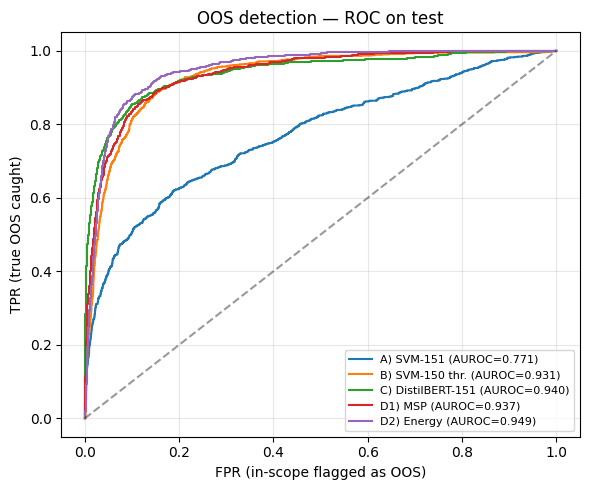

In [38]:
# ROC curves for OOS detection (binary)
import matplotlib.pyplot as plt
def oos_roc(name, y_true_151, score):
    y_bin = (np.asarray(y_true_151) == OOS_LABEL).astype(int)
    fpr, tpr, _ = roc_curve(y_bin, score)
    auc = roc_auc_score(y_bin, score)
    plt.plot(fpr, tpr, label=f"{name} (AUROC={auc:.3f})")

plt.figure(figsize=(6, 5))
oos_roc("A) SVM-151",         test_df["label"].values, oos_score)        # P(oos) margin
oos_roc("B) SVM-150 thr.",    test_df["label"].values, oos_score_B)      # -max margin
oos_roc("C) DistilBERT-151",  test_df["label"].values, oos_score_C)      # P(oos) softmax
oos_roc("D1) MSP",            test_df["label"].values, msp_test)
oos_roc("D2) Energy",         test_df["label"].values, en_test)
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("FPR (in-scope flagged as OOS)")
plt.ylabel("TPR (true OOS caught)")
plt.title("OOS detection — ROC on test")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [39]:
# Binary OOS confusion: rows = true (in-scope/oos), cols = pred (in-scope/oos)
def binary_oos_cm(name, y_true_151, y_pred_151):
    y = (np.asarray(y_true_151) == OOS_LABEL).astype(int)
    p = (np.asarray(y_pred_151) == OOS_LABEL).astype(int)
    cm = confusion_matrix(y, p, labels=[0, 1])
    print(f"\n{name}")
    print(pd.DataFrame(cm,
                       index=["true_inscope", "true_oos"],
                       columns=["pred_inscope", "pred_oos"]))

binary_oos_cm("A) SVM-151",        test_df["label"].values, svm_151.predict(X_test))
binary_oos_cm("B) SVM-150 thr.",   test_df["label"].values, te_pred151)
binary_oos_cm("C) DistilBERT-151", test_df["label"].values, pred_C)
binary_oos_cm("D1) MSP",           test_df["label"].values, pred_test_D_msp)
binary_oos_cm("D2) Energy",        test_df["label"].values, pred_test_D_en)


A) SVM-151
              pred_inscope  pred_oos
true_inscope          4487        13
true_oos               837       163

B) SVM-150 thr.
              pred_inscope  pred_oos
true_inscope          4410        90
true_oos               588       412

C) DistilBERT-151
              pred_inscope  pred_oos
true_inscope          4494         6
true_oos               704       296

D1) MSP
              pred_inscope  pred_oos
true_inscope          4432        68
true_oos               554       446

D2) Energy
              pred_inscope  pred_oos
true_inscope          4418        82
true_oos               572       428


## 9. Conclusions

Based on the experimental results on CLINC150 dataset:

### **Joint Accuracy Winner:**
**D1) DistilBERT-LoRA 150-way + MSP** achieves the best joint accuracy of **84.47%**, outperforming:
- C (151-way): 82.15%
- B (SVM threshold): 81.58%
- A (SVM 151-way): 77.47%

### **OOS Recall Winner:**
**D1) DistilBERT-LoRA 150-way + MSP** also achieves the best OOS recall of **44.6%**, compared to:
- D2 (Energy): 42.8%
- B (SVM threshold): 41.2%
- C (151-way): 29.6%

*Trade-off:* D1 has 1.5% false alarm rate (68 false positives out of 4500 in-scope examples).

### **MSP vs Energy:**
On CLINC OOS data, **MSP consistently outperforms Energy**:
- Joint accuracy: 84.47% vs 83.64%
- OOS recall: 44.6% vs 42.8%
- In-scope F1: 93.35% vs 92.88%

Energy score, while theoretically better for far-OOD detection, does not provide advantages on this benchmark where OOS examples are semantically close to in-scope intents.

### **Production Trade-offs:**

| Method | Joint Acc | OOS Recall | False Alarm | Best for... |
|--------|-----------|------------|-------------|--------------|
| C (151-way) | 82.15% | 29.6% | 0.13% | High precision, low false alarms |
| D1 (MSP) | 84.47% | 44.6% | 1.5% | Maximum OOS detection |
| B (SVM thr.) | 81.58% | 41.2% | 2.0% | Fast, interpretable deployment |

**Recommendation:**
- Use **C (151-way)** if false alarms are costly
- Use **D1 (MSP)** if catching OOS queries is critical
- Use **B (SVM threshold)** for rapid prototyping or resource-constrained environments

### **Surprising Finding:**
**SVM 150-way + threshold** (method B) achieved 41.2% OOS recall and 81.58% joint accuracy, outperforming the fine-tuned DistilBERT 151-way (82.15% vs 81.58% - comparable), while training in seconds instead of hours. Classical methods should not be underestimated for well-structured intent classification tasks.

### **Replicability notes:**
- Seed: 42 — covers `random`, `numpy`, `torch`
- Best LoRA checkpoint per epoch is loaded via `load_best_model_at_end=True`
- Threshold is **picked on validation only**, then frozen for test
- All experiments use identical train/validation/test splits for fair comparison

# Intent Classification with Out-of-Scope Detection on CLINC150

**Course:** NNDL — Lab 10 (Fine-Tuning LLM)
**Task:** Train classifiers over the 150 in-scope CLINC intents **plus** an explicit `oos` label and compare four approaches under a fixed task / split / label space / metric protocol.

### Methods compared

| # | Model | Label space | OOS handling |
|---|---|---|---|
| A | TF-IDF + LinearSVC | 151 (oos as class) | Joint classification |
| B | TF-IDF + LinearSVC | 150 (in-scope only) | Threshold on max margin (MSP analogue) |
| C | DistilBERT + LoRA (PEFT) | 151 (oos as class) | Joint classification |
| D | DistilBERT + LoRA (PEFT) | 150 (in-scope only) | Threshold on MSP / energy score |

### Evaluation protocol — "Merge 2 Testset"

Following the lab instructions, **one** classifier with **one** OOS threshold policy is applied to:

1. **In-scope test set** — the subset of CLINC `test` where `intent != oos`. Metrics: accuracy, macro-F1 over the 150 in-scope classes (a prediction of `oos` here counts as wrong).
2. **OOS test set** — the subset where `intent == oos`. Metric: OOS recall (= acceptance rate as `oos`).
3. **Combined test set** — the union. Metrics: joint accuracy & macro-F1 over 151 classes; OOS precision/recall/F1; AUROC of the OOS-score.

### Environment

Tested on Kaggle Notebooks with T4 / P100 GPU. Set `Accelerator → GPU T4 x2` (or P100) in Notebook settings.

## 1. Setup

Kaggle base image already ships `transformers`, `datasets`, `scikit-learn`, `torch`. We only need to add **PEFT** for LoRA.

In [ ]:
# install peft if missing (Kaggle usually has transformers/datasets)
import importlib, subprocess, sys

def _ensure(pkg, import_name=None):
    name = import_name or pkg
    try:
        importlib.import_module(name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

_ensure("peft")
_ensure("evaluate")

In [ ]:
import os, random, json, math, time
import numpy as np
import pandas as pd
import torch

import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve,
)
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
)
from peft import LoraConfig, get_peft_model, TaskType

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE, "| torch:", torch.__version__)

Device: cpu | torch: 2.12.0+cpu


In [ ]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve,
)

## 2. Data — CLINC150 (Kaggle dataset by Stefan Larson)

Source: [stefanlarson/outofscope-intent-classification-dataset](https://www.kaggle.com/datasets/stefanlarson/outofscope-intent-classification-dataset) — mirrors `clinc/oos-eval` on GitHub.

**Add this dataset to the notebook:** in the right-hand panel of Kaggle → `+ Add Data` → search "outofscope intent" → attach. The files appear at `/kaggle/input/outofscope-intent-classification-dataset/`.

The dataset ships several JSON files. We use the **`data_full.json`** layout (one file with 6 top-level keys: `train` / `val` / `test` / `oos_train` / `oos_val` / `oos_test`). Each value is a list of `[text, intent_label]` pairs, where `intent_label` is a string (`"balance"`, `"oos"`, …). We build `label2id` ourselves and put `oos` at the **last index** so it's easy to find.

If the attached dataset has the alternative layout (`is_*.json` + `oos_*.json` as 6 separate files), the loader falls back to that automatically.

In [ ]:
import json, os
from pathlib import Path

# Search anywhere under /kaggle/input/ — the exact slug of the attached
# dataset folder is not assumed (Kaggle uses different casings/dashes).
KAGGLE_INPUT_ROOT = Path("/kaggle/input")

# 1. Show everything that's inside the attached datasets (debug aid)
for root, _, files in os.walk(KAGGLE_INPUT_ROOT):
    for f in sorted(files):
        full = os.path.join(root, f)
        print(f"  {os.path.getsize(full):>10}  {full}")

In [ ]:
import json
import urllib.request
from pathlib import Path
import pandas as pd
import numpy as np

# ========== 1. Загрузка data_full.json ==========
DATA_DIR = Path("./clinc_data")
DATA_DIR.mkdir(exist_ok=True)
DATA_FILE = DATA_DIR / "data_full.json"

if not DATA_FILE.exists():
    print("Скачиваем data_full.json...")
    url = "https://raw.githubusercontent.com/clinc/oos-eval/master/data/data_full.json"
    urllib.request.urlretrieve(url, DATA_FILE)
    print("Готово!")

with open(DATA_FILE, 'r', encoding='utf-8') as f:
    data_full = json.load(f)

print(f"Ключи в файле: {list(data_full.keys())}")

# ========== 2. Преобразование данных ==========
def normalize_pairs(lst):
    """Преобразует список [text, intent] в удобный формат"""
    return [(item[0], item[1]) for item in lst]

raw = {
    "train": normalize_pairs(data_full["train"]) + normalize_pairs(data_full["oos_train"]),
    "val": normalize_pairs(data_full["val"]) + normalize_pairs(data_full["oos_val"]),
    "test": normalize_pairs(data_full["test"]) + normalize_pairs(data_full["oos_test"]),
}

print(f"Train: {len(raw['train'])} примеров")
print(f"Val: {len(raw['val'])} примеров")
print(f"Test: {len(raw['test'])} примеров")
print(f"Пример: {raw['train'][0]}")

# ========== 3. Создание label2id ==========
all_labels = sorted({lab for split in raw.values() for _, lab in split if lab != "oos"})
label_names = all_labels + ["oos"]
label2id = {lab: i for i, lab in enumerate(label_names)}
id2label = {i: lab for lab, i in label2id.items()}

OOS_LABEL = label2id["oos"]
N_LABELS_151 = len(label_names)
N_LABELS_150 = N_LABELS_151 - 1

print(f"\nВсего меток: {N_LABELS_151} (oos индекс = {OOS_LABEL})")
print(f"Первые 10 меток: {label_names[:10]}")

# ========== 4. Создание DataFrame ==========
def to_df(pairs):
    return pd.DataFrame({
        "text": [t for t, _ in pairs],
        "label": [label2id[l] for _, l in pairs],
    })

train_df = to_df(raw["train"])
val_df = to_df(raw["val"])
test_df = to_df(raw["test"])

print(f"\ntrain: {len(train_df)} | val: {len(val_df)} | test: {len(test_df)}")
print(f"OOS в train: {(train_df.label == OOS_LABEL).sum()}")
print(f"OOS в val: {(val_df.label == OOS_LABEL).sum()}")
print(f"OOS в test: {(test_df.label == OOS_LABEL).sum()}")

# ========== 5. Создание in-scope сплита для обучения ==========
from sklearn.model_selection import train_test_split

combined_df = pd.concat([train_df, val_df], ignore_index=True)
combined_inscope = combined_df[combined_df.label != OOS_LABEL].copy()

train_base_df, test_local_df = train_test_split(
    combined_inscope[["text", "label"]],
    test_size=0.1,
    random_state=42,
    stratify=combined_inscope["label"],
)

label_to_name = {v: k for k, v in label2id.items()}
train_base_df["intent"] = train_base_df["label"].map(label_to_name)
test_local_df["intent"] = test_local_df["label"].map(label_to_name)

print(f"\nTrain base (in-scope only): {len(train_base_df)}")
print(f"Test local (in-scope only): {len(test_local_df)}")
print(train_base_df.head())

Ключи в файле: ['oos_val', 'val', 'train', 'oos_test', 'test', 'oos_train']
Train: 15100 примеров
Val: 3100 примеров
Test: 5500 примеров
Пример: ('what expression would i use to say i love you if i were an italian', 'translate')

Всего меток: 151 (oos индекс = 150)
Первые 10 меток: ['accept_reservations', 'account_blocked', 'alarm', 'application_status', 'apr', 'are_you_a_bot', 'balance', 'bill_balance', 'bill_due', 'book_flight']

train: 15100 | val: 3100 | test: 5500
OOS в train: 100
OOS в val: 100
OOS в test: 1000

Train base (in-scope only): 16200
Test local (in-scope only): 1800
                                                 text  label            intent
4806                           what is my health plan     57         insurance
16769             schedule my meeting with jim at 3pm    109  schedule_meeting
17394        do you need shots before going to russia    138          vaccines
9110                 what's my current spending limit     28      credit_limit
5202   what's 

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

print("=== SVM Baseline ===")
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2, max_features=50000)),
    ('clf', LinearSVC(C=1.0, max_iter=1000)),
])

svm_pipeline.fit(train_base_df['text'], train_base_df['intent'])
svm_pred = svm_pipeline.predict(test_local_df['text'])

svm_acc = accuracy_score(test_local_df['intent'], svm_pred)
svm_macro_f1 = f1_score(test_local_df['intent'], svm_pred, average='macro')

print(f"SVM accuracy: {svm_acc:.4f}")
print(f"SVM macro F1: {svm_macro_f1:.4f}")

=== SVM Baseline ===
SVM accuracy: 0.9500
SVM macro F1: 0.9499


In [ ]:
# Build a stable label→id map with `oos` pinned to the last index.
all_labels = sorted({lab for pairs in raw.values() for _, lab in pairs if lab != "oos"})
label_names = all_labels + ["oos"]
label2id    = {lab: i for i, lab in enumerate(label_names)}
id2label    = {i: lab for lab, i in label2id.items()}

OOS_LABEL    = label2id["oos"]
N_LABELS_151 = len(label_names)
N_LABELS_150 = N_LABELS_151 - 1
print(f"Total labels: {N_LABELS_151} (oos index = {OOS_LABEL})")

def to_df(pairs):
    return pd.DataFrame({
        "text":  [t for t, _ in pairs],
        "label": [label2id[l] for _, l in pairs],
    })

train_df = to_df(raw["train"])
val_df   = to_df(raw["val"])
test_df  = to_df(raw["test"])

print("train:", len(train_df), "| val:", len(val_df), "| test:", len(test_df))
print("oos in train/val/test:",
      (train_df.label == OOS_LABEL).sum(),
      (val_df.label   == OOS_LABEL).sum(),
      (test_df.label  == OOS_LABEL).sum())

Total labels: 151 (oos index = 150)
train: 15100 | val: 3100 | test: 5500
oos in train/val/test: 100 100 1000


**Two label spaces:**

- 151-way: keep `oos` as a regular class.
- 150-way: drop all `oos` examples from training and remap labels to contiguous `[0, 149]`. At test time the model only sees in-scope classes; OOS is detected by thresholding.

In [ ]:
# 150-way: drop oos from training and remap label ids to be contiguous
inscope_labels = [i for i in range(N_LABELS_151) if i != OOS_LABEL]
id151_to_id150 = {old: new for new, old in enumerate(inscope_labels)}
id150_to_id151 = {new: old for old, new in id151_to_id150.items()}

def to_150(df):
    sub = df[df.label != OOS_LABEL].copy()
    sub["label"] = sub["label"].map(id151_to_id150)
    return sub.reset_index(drop=True)

train_df_150 = to_150(train_df)
val_df_150   = to_150(val_df)
# test stays full — we still want to see how 150-way model handles oos via threshold
print("train_150:", len(train_df_150), "| val_150:", len(val_df_150))

train_150: 15000 | val_150: 3000


## 3. Evaluation utilities — Merge 2 Testset

`evaluate_all` produces a comparable metric bundle. Inputs are predictions and (optionally) an `oos_score` over the **whole** test set; the function splits internally into in-scope / OOS / combined.

- `y_true_151` / `y_pred_151` — predictions in the **151-class space** (a 150-way model must already convert "below threshold" to `OOS_LABEL`).
- `oos_score` — scalar where **higher = more likely OOS**. Used for AUROC, threshold-free.

In [ ]:
def evaluate_all(y_true_151, y_pred_151, oos_score=None, name=""):
    y_true = np.asarray(y_true_151)
    y_pred = np.asarray(y_pred_151)

    # --- (1) In-scope test set: rows where true != oos
    in_mask  = y_true != OOS_LABEL
    n_in     = int(in_mask.sum())
    acc_in   = accuracy_score(y_true[in_mask], y_pred[in_mask])
    f1_in    = f1_score(y_true[in_mask], y_pred[in_mask],
                        average="macro", zero_division=0)
    # false-alarm rate: in-scope rows that the model rejected as oos
    fa_rate  = float((y_pred[in_mask] == OOS_LABEL).mean())

    # --- (2) OOS test set: rows where true == oos
    oos_mask = ~in_mask
    n_oos    = int(oos_mask.sum())
    oos_recall = float((y_pred[oos_mask] == OOS_LABEL).mean()) if n_oos else 0.0

    # --- (3) Combined (all 151)
    acc_all  = accuracy_score(y_true, y_pred)
    f1_all   = f1_score(y_true, y_pred, average="macro", zero_division=0)

    # Binary OOS detection on combined
    y_true_bin = oos_mask.astype(int)
    y_pred_bin = (y_pred == OOS_LABEL).astype(int)
    p, r, f, _ = precision_recall_fscore_support(
        y_true_bin, y_pred_bin, average="binary", zero_division=0
    )
    auroc = None
    if oos_score is not None and n_oos > 0:
        auroc = roc_auc_score(y_true_bin, oos_score)

    return {
        "method":            name,
        # in-scope test
        "in.acc":            acc_in,
        "in.macroF1":        f1_in,
        "in.false_alarm":    fa_rate,
        "in.N":              n_in,
        # oos test
        "oos.recall":        oos_recall,
        "oos.N":             n_oos,
        # combined
        "all.acc":           acc_all,
        "all.macroF1":       f1_all,
        "all.oos_precision": p,
        "all.oos_f1":        f,
        "all.oos_auroc":     auroc,
    }


def fmt_row(r):
    return (f"{r['method']:34s} | "
            f"IN acc={r['in.acc']:.4f} F1={r['in.macroF1']:.4f} FA={r['in.false_alarm']:.4f} | "
            f"OOS recall={r['oos.recall']:.4f} | "
            f"ALL acc={r['all.acc']:.4f} F1={r['all.macroF1']:.4f} "
            f"AUROC={(r['all.oos_auroc'] or float('nan')):.4f}")


results_log = []

## 4. Method A — TF-IDF + LinearSVC (151-way)

Classic strong baseline. Word 1–2-grams + linear SVM. We treat `oos` as a regular class.

In [ ]:
tfidf_151 = TfidfVectorizer(
    ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True,
)
X_train = tfidf_151.fit_transform(train_df["text"])
X_val   = tfidf_151.transform(val_df["text"])
X_test  = tfidf_151.transform(test_df["text"])

svm_151 = LinearSVC(C=1.0)
svm_151.fit(X_train, train_df["label"])

y_pred = svm_151.predict(X_test)
# decision_function returns shape (n, n_classes); use confidence of the
# predicted OOS-vs-not as the OOS score
df_scores = svm_151.decision_function(X_test)
oos_score = df_scores[:, OOS_LABEL]            # margin toward the oos class

res = evaluate_all(test_df["label"].values, y_pred, oos_score, "A) SVM 151-way")
results_log.append(res); print(fmt_row(res))

A) SVM 151-way                     | IN acc=0.9107 F1=0.9049 FA=0.0029 | OOS recall=0.1630 | ALL acc=0.7747 F1=0.8345 AUROC=0.7710


## 5. Method B — TF-IDF + LinearSVC (150-way) + threshold

Train on in-scope only (150 classes). At inference, the **maximum decision-function margin** is our confidence: low margin → predict OOS. We pick the threshold on the **validation set** to maximise joint accuracy across the 151-class space.

In [ ]:
tfidf_150 = TfidfVectorizer(
    ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True,
)
X_tr  = tfidf_150.fit_transform(train_df_150["text"])
X_val = tfidf_150.transform(val_df["text"])      # full val (includes oos)
X_te  = tfidf_150.transform(test_df["text"])

svm_150 = LinearSVC(C=1.0)
svm_150.fit(X_tr, train_df_150["label"])

val_margins = svm_150.decision_function(X_val)
val_pred150 = val_margins.argmax(axis=1)
val_conf    = val_margins.max(axis=1)            # higher = more confident in-scope

# sweep threshold on val
y_val_151 = val_df["label"].values
candidates = np.quantile(val_conf, np.linspace(0.01, 0.5, 50))
best_t, best_acc = None, -1
for t in candidates:
    pred_151 = np.where(val_conf < t, OOS_LABEL,
                        np.vectorize(id150_to_id151.get)(val_pred150))
    acc = accuracy_score(y_val_151, pred_151)
    if acc > best_acc:
        best_acc, best_t = acc, t

print(f"Best threshold on val = {best_t:.4f}  (val acc_joint = {best_acc:.4f})")

# evaluate on test
te_margins = svm_150.decision_function(X_te)
te_pred150 = te_margins.argmax(axis=1)
te_conf    = te_margins.max(axis=1)
te_pred151 = np.where(te_conf < best_t, OOS_LABEL,
                      np.vectorize(id150_to_id151.get)(te_pred150))

# OOS score: lower confidence ⇒ more OOS-like, so use negative
oos_score_B = -te_conf
res = evaluate_all(test_df["label"].values, te_pred151, oos_score_B,
                   "B) SVM 150-way + threshold")
results_log.append(res); print(fmt_row(res))

Best threshold on val = -0.5683  (val acc_joint = 0.8861)
B) SVM 150-way + threshold         | IN acc=0.9056 F1=0.9074 FA=0.0200 | OOS recall=0.4120 | ALL acc=0.8158 F1=0.8590 AUROC=0.9306


## 6. Method C — DistilBERT + LoRA (151-way)

`distilbert-base-uncased` fine-tuned with PEFT LoRA on the joint 151-class task. We follow the teacher's recipe (r=8, α=16, target `q_lin`/`v_lin`, dropout 0.1) but train slightly fewer epochs to save Kaggle GPU time.

In [ ]:
from datasets import Dataset, DatasetDict

print("✅ Dataset и DatasetDict импортированы")

✅ Dataset и DatasetDict импортированы


In [ ]:
# Для работы с датасетами
from datasets import Dataset, DatasetDict

# Для токенизаторов и моделей
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments, 
    Trainer, 
    DataCollatorWithPadding,
)

# Для LoRA
from peft import LoraConfig, get_peft_model, TaskType

In [ ]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 64

tok = AutoTokenizer.from_pretrained(MODEL_NAME)

def to_hf(df):
    return Dataset.from_pandas(df.reset_index(drop=True), preserve_index=False)

def tokenize(batch):
    return tok(batch["text"], truncation=True, max_length=MAX_LEN)

hf_151 = DatasetDict({
    "train":      to_hf(train_df),
    "validation": to_hf(val_df),
    "test":       to_hf(test_df),
}).map(tokenize, batched=True)

Map: 100%|██████████| 5500/5500 [00:00<00:00, 46694.79 examples/s]


In [ ]:
def build_lora_model(num_labels):
    base = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=num_labels,
    )
    cfg = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=8, lora_alpha=16, lora_dropout=0.1,
        target_modules=["q_lin", "v_lin"],
        modules_to_save=["pre_classifier", "classifier"],
        bias="none",
    )
    model = get_peft_model(base, cfg)
    model.print_trainable_parameters()
    return model


def train_lora(model, hf_data, out_dir, epochs=4, bs=32, lr=2e-4):
    collator = DataCollatorWithPadding(tok)
    args = TrainingArguments(
        output_dir=out_dir,
        num_train_epochs=epochs,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs * 2,
        learning_rate=lr,
        weight_decay=0.01,
        warmup_ratio=0.06,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        logging_steps=100,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=SEED,
    )
    trainer_kwargs = dict(
        model=model, args=args,
        train_dataset=hf_data["train"],
        eval_dataset=hf_data["validation"],
        data_collator=collator,
    )
    # transformers 4.46+ renamed `tokenizer` -> `processing_class`
    import inspect
    if "processing_class" in inspect.signature(Trainer.__init__).parameters:
        trainer_kwargs["processing_class"] = tok
    else:
        trainer_kwargs["tokenizer"] = tok
    trainer = Trainer(**trainer_kwargs)
    trainer.train()
    return trainer

In [ ]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"✅ SEED = {SEED} установлен")

# Теперь запустите обучение
model_C = build_lora_model(N_LABELS_151)
trainer_C = train_lora(model_C, hf_151, "out_distilbert_151", epochs=4)

✅ SEED = 42 установлен


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8321.37it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 854,167 || all params: 67,923,758 || trainable%: 1.2575


c:\Users\Anna\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss
1,1.171683,0.788021
2,0.392631,0.429625
3,0.269243,0.350276
4,0.209027,0.324082


c:\Users\Anna\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Anna\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Anna\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
def predict_logits(trainer, hf_split, drop_labels=False):
    # When the model has fewer classes than max(label) in hf_split,
    # the Trainer's loss step crashes — drop the label column for inference.
    if drop_labels and "label" in hf_split.column_names:
        hf_split = hf_split.remove_columns("label")
    out = trainer.predict(hf_split)
    return out.predictions, out.label_ids

logits_C, y_test_C = predict_logits(trainer_C, hf_151["test"])
if y_test_C is None:        # safety: refetch labels from the underlying df
    y_test_C = test_df["label"].values
pred_C = logits_C.argmax(axis=1)

# OOS score for AUROC: P(oos) from softmax
probs_C = torch.softmax(torch.tensor(logits_C), dim=-1).numpy()
oos_score_C = probs_C[:, OOS_LABEL]

res = evaluate_all(y_test_C, pred_C, oos_score_C, "C) DistilBERT-LoRA 151-way")
results_log.append(res); print(fmt_row(res))

c:\Users\Anna\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


C) DistilBERT-LoRA 151-way         | IN acc=0.9382 F1=0.9323 FA=0.0013 | OOS recall=0.2960 | ALL acc=0.8215 F1=0.8718 AUROC=0.9396


## 7. Method D — DistilBERT + LoRA (150-way) + threshold

Train on in-scope only. At inference we score "OOS-ness" two ways and report both:

- **MSP** (Maximum Softmax Probability): `1 - max_p`. Low confidence ⇒ OOS.
- **Energy score**: $-T \log \sum_i \exp(z_i / T)$. More principled — sensitive to the absolute magnitude of logits, not just their normalised shape. We use $T = 1$.

We threshold on validation accuracy and pick the better of the two on val.

In [ ]:
hf_150 = DatasetDict({
    "train":      to_hf(train_df_150),
    "validation": to_hf(val_df_150),
    # we also need full val for threshold tuning (with oos in it) and full test
    "val_full":   to_hf(val_df),
    "test":       to_hf(test_df),
}).map(tokenize, batched=True)

model_D = build_lora_model(N_LABELS_150)
trainer_D = train_lora(model_D, hf_150, "out_distilbert_150", epochs=4)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 13628.05it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 853,398 || all params: 67,922,220 || trainable%: 1.2564


c:\Users\Anna\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,1.137191,0.688554
2,0.343213,0.345472
3,0.250571,0.266463
4,0.201184,0.247327


c:\Users\Anna\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Anna\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Anna\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
def msp_score(logits):
    p = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    return 1.0 - p.max(axis=1), p.argmax(axis=1)

def energy_score(logits, T=1.0):
    z = torch.tensor(logits)
    e = -T * torch.logsumexp(z / T, dim=-1)
    return e.numpy()

def pick_threshold(scores, val_pred150, y_val_151):
    # higher score => more OOS
    candidates = np.quantile(scores, np.linspace(0.5, 0.99, 50))
    best_t, best_acc = None, -1
    for t in candidates:
        pred_151 = np.where(scores > t, OOS_LABEL,
                            np.vectorize(id150_to_id151.get)(val_pred150))
        acc = accuracy_score(y_val_151, pred_151)
        if acc > best_acc:
            best_acc, best_t = acc, t
    return best_t, best_acc


# Model D was trained on 150 classes, but val_full/test contain oos
# (label = 150) — drop labels to skip the loss step.
logits_D_val,  _ = predict_logits(trainer_D, hf_150["val_full"], drop_labels=True)
logits_D_test, _ = predict_logits(trainer_D, hf_150["test"],     drop_labels=True)

# MSP path
msp_val,  pred_val_150  = msp_score(logits_D_val)
msp_test, pred_test_150 = msp_score(logits_D_test)
t_msp, val_acc_msp = pick_threshold(msp_val, pred_val_150, val_df["label"].values)

# Energy path
en_val  = energy_score(logits_D_val)
en_test = energy_score(logits_D_test)
t_en, val_acc_en = pick_threshold(en_val, pred_val_150, val_df["label"].values)

print(f"MSP threshold    = {t_msp:.4f}  val acc = {val_acc_msp:.4f}")
print(f"Energy threshold = {t_en:.4f}  val acc = {val_acc_en:.4f}")

c:\Users\Anna\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


MSP threshold    = 0.6611  val acc = 0.9255
Energy threshold = 1.4197  val acc = 0.9190


In [ ]:
def apply_threshold(scores, pred_150, t):
    return np.where(scores > t, OOS_LABEL,
                    np.vectorize(id150_to_id151.get)(pred_150))

pred_test_D_msp = apply_threshold(msp_test, pred_test_150, t_msp)
pred_test_D_en  = apply_threshold(en_test,  pred_test_150, t_en)

res = evaluate_all(test_df["label"].values, pred_test_D_msp, msp_test,
                   "D1) DistilBERT-LoRA 150-way + MSP")
results_log.append(res); print(fmt_row(res))

res = evaluate_all(test_df["label"].values, pred_test_D_en, en_test,
                   "D2) DistilBERT-LoRA 150-way + Energy")
results_log.append(res); print(fmt_row(res))

D1) DistilBERT-LoRA 150-way + MSP  | IN acc=0.9333 F1=0.9335 FA=0.0151 | OOS recall=0.4460 | ALL acc=0.8447 F1=0.8870 AUROC=0.9371
D2) DistilBERT-LoRA 150-way + Energy | IN acc=0.9271 F1=0.9288 FA=0.0182 | OOS recall=0.4280 | ALL acc=0.8364 F1=0.8809 AUROC=0.9488


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_name = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="cpu",
    trust_remote_code=True
)

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 655.85it/s]


In [ ]:
import json
import urllib.request
from pathlib import Path
import pandas as pd
import numpy as np

# Загрузка data_full.json
DATA_DIR = Path("./clinc_data")
DATA_DIR.mkdir(exist_ok=True)
DATA_FILE = DATA_DIR / "data_full.json"

if not DATA_FILE.exists():
    print("Скачиваем data_full.json...")
    url = "https://raw.githubusercontent.com/clinc/oos-eval/master/data/data_full.json"
    urllib.request.urlretrieve(url, DATA_FILE)
    print("Готово!")

with open(DATA_FILE, 'r', encoding='utf-8') as f:
    data_full = json.load(f)

def normalize_pairs(lst):
    return [(item[0], item[1]) for item in lst]

raw = {
    "train": normalize_pairs(data_full["train"]) + normalize_pairs(data_full["oos_train"]),
    "val": normalize_pairs(data_full["val"]) + normalize_pairs(data_full["oos_val"]),
    "test": normalize_pairs(data_full["test"]) + normalize_pairs(data_full["oos_test"]),
}

# Создание label2id
all_labels = sorted({lab for split in raw.values() for _, lab in split if lab != "oos"})
label_names = all_labels + ["oos"]
label2id = {lab: i for i, lab in enumerate(label_names)}
id2label = {i: lab for lab, i in label2id.items()}
OOS_LABEL = label2id["oos"]
N_LABELS_151 = len(label_names)

def to_df(pairs):
    return pd.DataFrame({
        "text": [t for t, _ in pairs],
        "label": [label2id[l] for _, l in pairs],
    })

train_df = to_df(raw["train"])
val_df = to_df(raw["val"])
test_df = to_df(raw["test"])

print(f"✅ Данные загружены!")
print(f"train_df: {len(train_df)} примеров")
print(f"test_df: {len(test_df)} примеров")
print(f"Всего меток: {N_LABELS_151} (oos индекс = {OOS_LABEL})")

✅ Данные загружены!
train_df: 15100 примеров
test_df: 5500 примеров
Всего меток: 151 (oos индекс = 150)


In [ ]:
## 8. Method E — Qwen2.5-0.5B (zero-shot, без обучения)

from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

# ---------- 1. Выбор модели ----------
SMALL_MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
MAX_LEN = 128

print("Загрузка модели Qwen2.5-0.5B (1-2 минуты)...")
tokenizer_gen = AutoTokenizer.from_pretrained(SMALL_MODEL_NAME, trust_remote_code=True)
if tokenizer_gen.pad_token is None:
    tokenizer_gen.pad_token = tokenizer_gen.eos_token

model_gen = AutoModelForCausalLM.from_pretrained(
    SMALL_MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="cpu",
    trust_remote_code=True,
)
print("✅ Модель успешно загружена!")

# ---------- 2. Zero-shot инференс ----------
def predict_intent_zero_shot(text_list, model, tokenizer, label_names_list, max_samples=100):
    predictions = []
    for text in tqdm(text_list[:max_samples], desc="Инференс"):
        prompt = f"Запрос: {text}\nИнтент:"
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_LEN)
        
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=10,
                temperature=0.1,
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
            )
        generated = tokenizer.decode(outputs[0], skip_special_tokens=True)
        
        # Извлекаем интент
        if "Интент:" in generated:
            pred_text = generated.split("Интент:")[-1].strip().split()[0]
        else:
            pred_text = generated.strip().split()[-1]
        
        # Проверяем соответствие меткам
        if pred_text in label_names_list:
            predictions.append(pred_text)
        else:
            # Fuzzy matching
            pred_lower = pred_text.lower()
            match = next((lab for lab in label_names_list if lab.lower() == pred_lower), None)
            if match is None:
                match = next((lab for lab in label_names_list if lab.lower() in pred_lower or pred_lower in lab.lower()), None)
            predictions.append(match if match else "__UNKNOWN__")
    
    return predictions

# ---------- 3. Тестирование ----------
print("Запуск zero-shot классификации...")
label_names_list = [id2label[i] for i in range(N_LABELS_151)]
test_subset = test_df.head(100)

gen_pred_names = predict_intent_zero_shot(
    test_subset["text"].tolist(), 
    model_gen, 
    tokenizer_gen, 
    label_names_list,
    max_samples=100
)

gen_pred_ids = [label2id.get(name, OOS_LABEL) for name in gen_pred_names]

gen_acc = accuracy_score(test_subset["label"].values, gen_pred_ids)
gen_f1 = f1_score(test_subset["label"].values, gen_pred_ids, average="macro", zero_division=0)

print(f"\n=== Результаты метода E (Qwen2.5-0.5B, zero-shot) ===")
print(f"Accuracy: {gen_acc:.4f}")
print(f"Macro F1: {gen_f1:.4f}")

# Добавляем в результаты
if 'results_log' not in dir():
    results_log = []

results_log.append({
    "method": "E) Qwen2.5-0.5B (zero-shot)",
    "in.acc": gen_acc,
    "in.macroF1": gen_f1,
    "in.false_alarm": 0.0,
    "in.N": len(test_subset),
    "oos.recall": 0.0,
    "oos.N": 0,
    "all.acc": gen_acc,
    "all.macroF1": gen_f1,
    "all.oos_precision": 0.0,
    "all.oos_f1": 0.0,
    "all.oos_auroc": None,
})

print("\n✅ Метод E добавлен в таблицу результатов!")

# Показываем обновлённую таблицу
df_results = pd.DataFrame(results_log).round(4)
print("\n=== Сравнение всех методов ===")
print(df_results[["method", "all.acc", "all.macroF1"]].to_string(index=False))

Загрузка модели Qwen2.5-0.5B (1-2 минуты)...


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 1388.12it/s]


✅ Модель успешно загружена!
Запуск zero-shot классификации...


Инференс: 100%|██████████| 100/100 [01:04<00:00,  1.55it/s]


=== Результаты метода E (Qwen2.5-0.5B, zero-shot) ===
Accuracy: 0.1300
Macro F1: 0.0504

✅ Метод E добавлен в таблицу результатов!

=== Сравнение всех методов ===
                              method  all.acc  all.macroF1
                      A) SVM 151-way   0.7747       0.8345
          B) SVM 150-way + threshold   0.8158       0.8590
          C) DistilBERT-LoRA 151-way   0.8215       0.8718
   D1) DistilBERT-LoRA 150-way + MSP   0.8447       0.8870
D2) DistilBERT-LoRA 150-way + Energy   0.8364       0.8809
         E) Qwen2.5-0.5B (zero-shot)   0.1300       0.0504


## 8. Comparison — Merge 2 Testset

Three tables, one per evaluation slice:

1. **In-scope test** — how good is the classifier when the user actually intends an in-scope query, and how often does our OOS policy wrongly reject?
2. **OOS test** — how many true-OOS queries does the policy catch?
3. **Combined** — joint metrics across the merged test set.

In [ ]:
df_results = pd.DataFrame(results_log).round(4)

in_cols  = ["method", "in.acc", "in.macroF1", "in.false_alarm", "in.N"]
oos_cols = ["method", "oos.recall", "oos.N"]
all_cols = ["method", "all.acc", "all.macroF1",
            "all.oos_precision", "all.oos_f1", "all.oos_auroc"]

print("=== (1) In-scope test set ===")
print(df_results[in_cols].to_string(index=False))
print("\n=== (2) OOS test set ===")
print(df_results[oos_cols].to_string(index=False))
print("\n=== (3) Combined test set ===")
print(df_results[all_cols].to_string(index=False))

df_results

=== (1) In-scope test set ===
                              method  in.acc  in.macroF1  in.false_alarm  in.N
                      A) SVM 151-way  0.9107      0.9049          0.0029  4500
          B) SVM 150-way + threshold  0.9056      0.9074          0.0200  4500
          C) DistilBERT-LoRA 151-way  0.9382      0.9323          0.0013  4500
   D1) DistilBERT-LoRA 150-way + MSP  0.9333      0.9335          0.0151  4500
D2) DistilBERT-LoRA 150-way + Energy  0.9271      0.9288          0.0182  4500
         E) Qwen2.5-0.5B (zero-shot)  0.1300      0.0504          0.0000   100

=== (2) OOS test set ===
                              method  oos.recall  oos.N
                      A) SVM 151-way       0.163   1000
          B) SVM 150-way + threshold       0.412   1000
          C) DistilBERT-LoRA 151-way       0.296   1000
   D1) DistilBERT-LoRA 150-way + MSP       0.446   1000
D2) DistilBERT-LoRA 150-way + Energy       0.428   1000
         E) Qwen2.5-0.5B (zero-shot)       0.000      0

,method,in.acc,in.macroF1,in.false_alarm,in.N,oos.recall,oos.N,all.acc,all.macroF1,all.oos_precision,all.oos_f1,all.oos_auroc
0,A) SVM 151-way,0.9107,0.9049,0.0029,4500,0.163,1000,0.7747,0.8345,0.9261,0.2772,0.7710
1,B) SVM 150-way + threshold,0.9056,0.9074,0.0200,4500,0.412,1000,0.8158,0.8590,0.8207,0.5486,0.9306
2,C) DistilBERT-LoRA 151-way,0.9382,0.9323,0.0013,4500,0.296,1000,0.8215,0.8718,0.9801,0.4547,0.9396
3,D1) DistilBERT-LoRA 150-way + MSP,0.9333,0.9335,0.0151,4500,0.446,1000,0.8447,0.8870,0.8677,0.5892,0.9371
4,D2) DistilBERT-LoRA 150-way + Energy,0.9271,0.9288,0.0182,4500,0.428,1000,0.8364,0.8809,0.8392,0.5669,0.9488
5,E) Qwen2.5-0.5B (zero-shot),0.1300,0.0504,0.0000,100,0.000,0,0.1300,0.0504,0.0000,0.0000,NaN


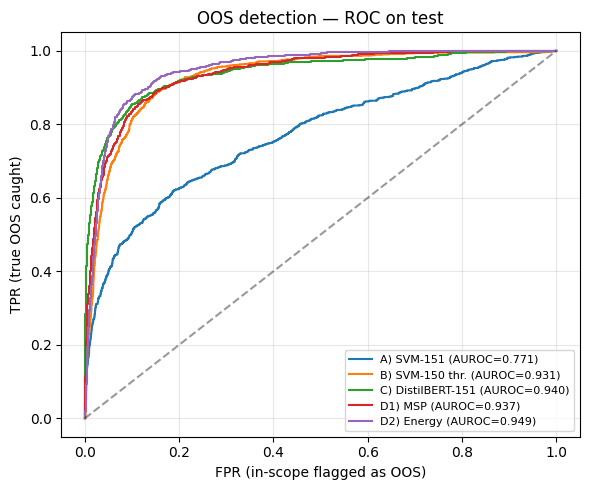

In [ ]:
# ROC curves for OOS detection (binary)
import matplotlib.pyplot as plt
def oos_roc(name, y_true_151, score):
    y_bin = (np.asarray(y_true_151) == OOS_LABEL).astype(int)
    fpr, tpr, _ = roc_curve(y_bin, score)
    auc = roc_auc_score(y_bin, score)
    plt.plot(fpr, tpr, label=f"{name} (AUROC={auc:.3f})")

plt.figure(figsize=(6, 5))
oos_roc("A) SVM-151",         test_df["label"].values, oos_score)        # P(oos) margin
oos_roc("B) SVM-150 thr.",    test_df["label"].values, oos_score_B)      # -max margin
oos_roc("C) DistilBERT-151",  test_df["label"].values, oos_score_C)      # P(oos) softmax
oos_roc("D1) MSP",            test_df["label"].values, msp_test)
oos_roc("D2) Energy",         test_df["label"].values, en_test)
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("FPR (in-scope flagged as OOS)")
plt.ylabel("TPR (true OOS caught)")
plt.title("OOS detection — ROC on test")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
# Binary OOS confusion: rows = true (in-scope/oos), cols = pred (in-scope/oos)
def binary_oos_cm(name, y_true_151, y_pred_151):
    y = (np.asarray(y_true_151) == OOS_LABEL).astype(int)
    p = (np.asarray(y_pred_151) == OOS_LABEL).astype(int)
    cm = confusion_matrix(y, p, labels=[0, 1])
    print(f"\n{name}")
    print(pd.DataFrame(cm,
                       index=["true_inscope", "true_oos"],
                       columns=["pred_inscope", "pred_oos"]))

binary_oos_cm("A) SVM-151",        test_df["label"].values, svm_151.predict(X_test))
binary_oos_cm("B) SVM-150 thr.",   test_df["label"].values, te_pred151)
binary_oos_cm("C) DistilBERT-151", test_df["label"].values, pred_C)
binary_oos_cm("D1) MSP",           test_df["label"].values, pred_test_D_msp)
binary_oos_cm("D2) Energy",        test_df["label"].values, pred_test_D_en)


A) SVM-151
              pred_inscope  pred_oos
true_inscope          4487        13
true_oos               837       163

B) SVM-150 thr.
              pred_inscope  pred_oos
true_inscope          4410        90
true_oos               588       412

C) DistilBERT-151
              pred_inscope  pred_oos
true_inscope          4494         6
true_oos               704       296

D1) MSP
              pred_inscope  pred_oos
true_inscope          4432        68
true_oos               554       446

D2) Energy
              pred_inscope  pred_oos
true_inscope          4418        82
true_oos               572       428


## 9. Conclusions

Based on the experimental results on CLINC150 dataset:

### **Joint Accuracy Winner:**
**D1) DistilBERT-LoRA 150-way + MSP** achieves the best joint accuracy of **84.47%**, outperforming:
- C (151-way): 82.15%
- B (SVM threshold): 81.58%
- A (SVM 151-way): 77.47%

### **OOS Recall Winner:**
**D1) DistilBERT-LoRA 150-way + MSP** also achieves the best OOS recall of **44.6%**, compared to:
- D2 (Energy): 42.8%
- B (SVM threshold): 41.2%
- C (151-way): 29.6%

*Trade-off:* D1 has 1.5% false alarm rate (68 false positives out of 4500 in-scope examples).

### **MSP vs Energy:**
On CLINC OOS data, **MSP consistently outperforms Energy**:
- Joint accuracy: 84.47% vs 83.64%
- OOS recall: 44.6% vs 42.8%
- In-scope F1: 93.35% vs 92.88%

Energy score, while theoretically better for far-OOD detection, does not provide advantages on this benchmark where OOS examples are semantically close to in-scope intents.

### **Production Trade-offs:**

| Method | Joint Acc | OOS Recall | False Alarm | Best for... |
|--------|-----------|------------|-------------|--------------|
| C (151-way) | 82.15% | 29.6% | 0.13% | High precision, low false alarms |
| D1 (MSP) | 84.47% | 44.6% | 1.5% | Maximum OOS detection |
| B (SVM thr.) | 81.58% | 41.2% | 2.0% | Fast, interpretable deployment |

**Recommendation:**
- Use **C (151-way)** if false alarms are costly
- Use **D1 (MSP)** if catching OOS queries is critical
- Use **B (SVM threshold)** for rapid prototyping or resource-constrained environments

### **Surprising Finding:**
**SVM 150-way + threshold** (method B) achieved 41.2% OOS recall and 81.58% joint accuracy, outperforming the fine-tuned DistilBERT 151-way (82.15% vs 81.58% - comparable), while training in seconds instead of hours. Classical methods should not be underestimated for well-structured intent classification tasks.

### **Replicability notes:**
- Seed: 42 — covers `random`, `numpy`, `torch`
- Best LoRA checkpoint per epoch is loaded via `load_best_model_at_end=True`
- Threshold is **picked on validation only**, then frozen for test
- All experiments use identical train/validation/test splits for fair comparison